In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



## Initialize environment and agent

In [4]:
def setup_env_and_agent(checkpoint_path,
                        task_name='cartpole-swingup',
                        obs_type='state',
                        seed=0,
                        compile_flag=False,
                        mpc_flag=True,
                        multitask_flag=False,
                        model_size_val=5):
    """
    Sets up the configuration, environment, and agent for a given checkpoint path.
    Returns: (cfg, env, agent)
    """
    override_cfg = dict(
        task=task_name,
        checkpoint=checkpoint_path,
        obs=obs_type,
        seed=seed,
        compile=compile_flag,
        mpc=mpc_flag,
        multitask=multitask_flag,
        model_size=model_size_val,
    )

    with initialize(config_path="tdmpc2", version_base=None):
        cfg = compose(config_name="config")
        OmegaConf.set_struct(cfg, False)
        cfg = OmegaConf.merge(cfg, override_cfg)

    # Parse config
    cfg = parse_cfg(cfg)
    set_seed(cfg.seed)

    cfg.initial_state = {
        'qpos': {
            'slider': 0,  # cart position
            'hinge_1': 0,  # pole angle
        },
    }

    env = make_env(cfg)

    print("\nLoading agent...")
    agent = TDMPC2(cfg)

    # Optionally load checkpoint
    if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
        print(f"Loading checkpoint: {cfg.checkpoint}")
        agent.load(cfg.checkpoint)

    return agent


# Example usage (uncomment and set your checkpoint):
#agent_1 = setup_env_and_agent(
#    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-1.pt')

agent_2 = setup_env_and_agent(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-2.pt')

agent_3 = setup_env_and_agent(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt')

agent_500k = setup_env_and_agent(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt'
)

agent_noncentered = setup_env_and_agent(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-noncentered.pt')

agent_m30_317M = setup_env_and_agent(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/mt30-317M.pt',
    task_name='mt30',
    model_size_val=317,
    multitask_flag=True)



Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-2.pt

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt

Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-noncentered.pt
Creating multi-task environment with tasks: ['walker-stand', 'walker-walk', 'walker-run', 'cheetah-run', 'reacher-easy', 'reacher-hard', 'acrobot-swingup', 'pendulum-swingup', 'cartpole-balance', 'cartpole-balance-sparse', 'cartpole-swingup', 'cartpole-swingup-sparse', 'cup-catch', 'finger-spin', 'finger-turn-easy', 'finger-turn-hard', 'fish-swim', 'hopper-stand', 'hopper-hop', 'wa

In [21]:
# agent_pixel = setup_env_and_agent(
#     '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt',
#     obs_type='rgb')


In [5]:
obs_uniform = np.load(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/obs_uniform_30k.npy'
)

In [6]:
obs_uniform_torch = torch.from_numpy(obs_uniform).to('cuda').float()
obs_uniform_torch_padded = torch.nn.functional.pad(
    obs_uniform_torch, (0, 24 - 5))  # pad last dim to 24
print(
    f"Padded shape: {obs_uniform_torch_padded.shape}")  # Should be [30000, 24]

Padded shape: torch.Size([30000, 24])


In [7]:
obs_uniform_torch.shape

torch.Size([30000, 5])

In [8]:
# Create task tensor (task=10 is cartpole-swingup)
task_tensor = torch.tensor([10], device=agent_m30_317M.device)
z_multitask = agent_m30_317M.model.encode(obs_uniform_torch_padded,
                                          task=task_tensor)

In [9]:
z_multitask.shape

torch.Size([30000, 1376])

In [10]:
z_agent_2 = agent_2.model.encode(obs_uniform_torch,
                                 task=None).detach().cpu().numpy()
z_agent_3 = agent_3.model.encode(obs_uniform_torch,
                                 task=None).detach().cpu().numpy()
z_agent_500k = agent_500k.model.encode(obs_uniform_torch,
                                       task=None).detach().cpu().numpy()
z_agent_noncentered = agent_noncentered.model.encode(
    obs_uniform_torch, task=None).detach().cpu().numpy()

z_agent_2.shape, z_agent_3.shape, z_agent_500k.shape, z_agent_noncentered.shape


((30000, 512), (30000, 512), (30000, 512), (30000, 512))

In [11]:
import numpy as np
import torch
from typing import List, Union, Tuple
import sklearn.linear_model
import matplotlib.pyplot as plt


def consistency_scores(
    embeddings: List[Union[np.ndarray, torch.Tensor]],
    datasets: List[Union[int, str]],
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the pairwise linear regression R2 scores (consistency scores)
    between all pairs of embeddings in the list.

    Args:
        embeddings: A list of 2D arrays (n_samples, n_features), each corresponding to a set of embeddings.
        datasets: A list of IDs or names associated with each embedding.

    Returns:
        r2_matrix: 2D numpy array of R^2 scores with shape (n, n), where n = len(embeddings).
        pairs: 2D list of dataset name pairs for each cell in the matrix.
    """
    if len(embeddings) <= 1:
        raise ValueError(
            f"Invalid list of embeddings, provide at least 2 embeddings to compare, got {len(embeddings)}."
        )
    if datasets is None:
        raise ValueError(
            "Missing datasets, provide a list of datasets_id associated to each embeddings to compare."
        )
    n = len(embeddings)
    r2_matrix = np.zeros((n, n))
    pairs = [[(datasets[i], datasets[j]) for j in range(n)] for i in range(n)]

    lin = sklearn.linear_model.LinearRegression()
    for i in range(n):
        ref_i = embeddings[i]
        if isinstance(ref_i, torch.Tensor):
            ref_i = ref_i.detach().cpu().numpy()
        for j in range(n):
            ref_j = embeddings[j]
            if isinstance(ref_j, torch.Tensor):
                ref_j = ref_j.detach().cpu().numpy()
            if i == j:
                r2_matrix[i, j] = 1.0  # perfect self-agreement
            else:
                # Linear regression from i to j
                try:
                    lin.fit(ref_i, ref_j)
                    r2 = lin.score(ref_i, ref_j)
                except Exception:
                    r2 = np.nan
                r2_matrix[i, j] = r2
    return r2_matrix, pairs


def plot_consistency_matrix(
    r2_matrix: np.ndarray,
    ax=None,
    cmap="magma",
    show_values: bool = True,
    xticks=None,
    yticks=None,
):
    """
    Plot the R2 consistency matrix as a confusion-matrix-like heatmap.

    Args:
        r2_matrix: 2D numpy array of pairwise R2 scores.
        ax: Optional matplotlib axis to plot into.
        cmap: Colormap for the matrix.
        show_values: Whether to annotate the cells with R2 values.
        xticks: Labels for the x-axis (target embeddings).
        yticks: Labels for the y-axis (source embeddings).
    """
    import matplotlib.pyplot as plt
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(r2_matrix, cmap=cmap, vmin=0, vmax=1)

    num_x = r2_matrix.shape[1]
    num_y = r2_matrix.shape[0]
    if xticks is not None:
        ax.set_xticks(np.arange(num_x))
        ax.set_xticklabels(xticks, rotation=45, ha="right")
    else:
        ax.set_xticks(np.arange(num_x))
        ax.set_xticklabels(np.arange(num_x), rotation=45, ha="right")
    if yticks is not None:
        ax.set_yticks(np.arange(num_y))
        ax.set_yticklabels(yticks)
    else:
        ax.set_yticks(np.arange(num_y))
        ax.set_yticklabels(np.arange(num_y))
    ax.set_xlabel('Target embeddings')
    ax.set_ylabel('Source embeddings')
    plt.colorbar(im,
                 ax=ax,
                 fraction=0.046,
                 pad=0.04,
                 label="Linear Regression $R^2$")
    if show_values:
        for i in range(r2_matrix.shape[0]):
            for j in range(r2_matrix.shape[1]):
                ax.text(j,
                        i,
                        f"{r2_matrix[i, j]:.2f}",
                        ha="center",
                        va="center",
                        color="black")
    plt.tight_layout()
    return ax


In [16]:
scores, pairs = consistency_scores(
    [z_agent_2, z_agent_3, z_agent_500k, z_agent_noncentered, z_multitask],
    datasets=[
        'agent_2', 'agent_3', 'agent_500k', 'agent_noncentered', 'multitask'
    ])

In [17]:
scores

array([[1.        , 0.97601938, 0.97426081, 0.97392488, 0.89723164],
       [0.98561311, 1.        , 0.98275244, 0.98713309, 0.91018319],
       [0.97545987, 0.97647166, 1.        , 0.99025244, 0.91001076],
       [0.96178705, 0.97171515, 0.98432291, 1.        , 0.89338046],
       [0.9853493 , 0.98163509, 0.98776925, 0.9904061 , 1.        ]])

<Axes: xlabel='Target embeddings', ylabel='Source embeddings'>

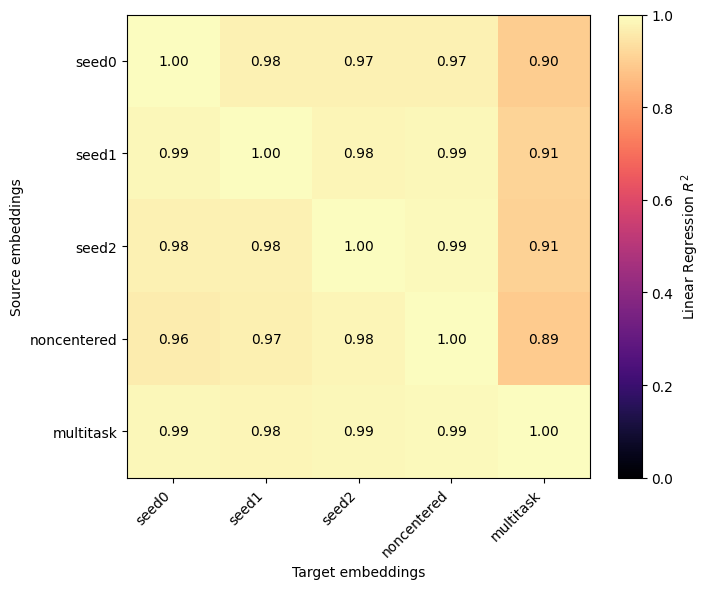

In [ ]:
plot_consistency_matrix(
    scores,
    xticks=['seed0', 'seed1', 'seed2', 'noncentered', 'multitask'],
    yticks=['seed0', 'seed1', 'seed2', 'noncentered', 'multitask'])